# Q-Learning (and SARSA): Temporal-Difference Control

**A hands-on tutorial with theory and a NumPy implementation**

---

**Q-learning**, introduced in Chris Watkins' 1989 PhD thesis and proven convergent by
[Watkins & Dayan (1992)](https://link.springer.com/article/10.1007/BF00992698), is arguably the most influential
algorithm in reinforcement learning. It was the first method to learn optimal behavior *directly from experience*,
without a model of the environment and without waiting for episodes to end — and it did so **off-policy**: the agent
can learn the optimal policy while behaving according to a completely different (exploratory) one.

Its importance is hard to overstate. When DeepMind's **DQN** learned to play Atari games from pixels in 2013, the
algorithm at its core was Q-learning with a neural network. Almost every value-based deep RL method since (Double DQN,
Rainbow, R2D2, Agent57) is a refinement of the update rule we implement in this notebook.

We also implement **SARSA** (Rummery & Niranjan, 1994), Q-learning's on-policy sibling, because the contrast between the two
on the classic *Cliff Walking* task is one of the most instructive experiments in all of RL.

## What you will learn

1. **Temporal-difference (TD) learning**: bootstrapping from sampled transitions instead of full returns or a model.
2. The **Q-learning** update and why it is *off-policy*.
3. The **SARSA** update and why it is *on-policy* — and how that changes the learned behavior.
4. $\varepsilon$-greedy exploration and the conditions for convergence.
5. A **from-scratch NumPy implementation** on `CliffWalking-v1` and `Taxi-v3`.
6. Where tabular Q-learning breaks and how DQN fixes it.

## Notebook outline

1. From dynamic programming to sampling: TD learning
2. Q-learning
3. SARSA and the on-policy / off-policy distinction
4. The Cliff Walking environment
5. Implementation
6. Experiment: Q-learning vs. SARSA on the cliff
7. Scaling up: Q-learning on Taxi-v3
8. **Visual demonstration** of the trained agents
9. Strengths, weaknesses & connections
10. References

## 0. Setup

This notebook is pure NumPy — no deep learning framework is needed. We use `gymnasium` (the maintained fork of
OpenAI Gym) for environments, `pygame` for rendering frames, and `imageio` to turn rendered frames into GIFs.
If you don't have these installed, uncomment the install cell.

In [1]:
# !pip install torch gymnasium pygame imageio matplotlib numpy

In [2]:
import time
import warnings
from collections import defaultdict

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="pkg_resources is deprecated")   # noisy pygame import warning

SEED = 42
rng = np.random.default_rng(SEED)
print(f"gymnasium version: {gym.__version__}")

gymnasium version: 1.2.3


### Visualization helpers

Every tutorial in this folder ends with a *visual demonstration* of the trained agent. The three helpers below are
shared across notebooks:

- `record_episode` rolls out one episode with a given action function and collects rendered RGB frames.
- `show_filmstrip` shows a handful of evenly spaced frames as a static image (renders everywhere, including GitHub).
- `save_gif` writes an animated GIF to `media/` and displays it inline.

In [3]:
import os
import imageio.v3 as iio
from IPython.display import Image, display

MEDIA_DIR = "media"
os.makedirs(MEDIA_DIR, exist_ok=True)


def record_episode(env, act_fn, seed=0, max_steps=1000):
    """Roll out one episode in an env created with render_mode="rgb_array".

    `act_fn(obs) -> action`. Returns (frames, episode_return, episode_length).
    """
    obs, _ = env.reset(seed=seed)
    frames, ep_ret = [env.render()], 0.0
    for _ in range(max_steps):
        obs, reward, terminated, truncated, _ = env.step(act_fn(obs))
        ep_ret += reward
        frames.append(env.render())
        if terminated or truncated:
            break
    return frames, ep_ret, len(frames) - 1


def show_filmstrip(frames, n=8, title=None, captions=None):
    """Static preview: n evenly spaced frames side by side."""
    idx = np.linspace(0, len(frames) - 1, num=min(n, len(frames)), dtype=int)
    h, w = np.asarray(frames[0]).shape[:2]
    fw = 2.3
    fig, axes = plt.subplots(1, len(idx), figsize=(fw * len(idx), fw * h / w + 0.6))
    for ax, i in zip(np.atleast_1d(axes), idx):
        ax.imshow(frames[i])
        ax.axis("off")
        ax.set_title(captions[i] if captions is not None else f"t = {i}", fontsize=9)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def save_gif(frames, name, fps=30, max_frames=240, downscale=2):
    """Subsample/downscale frames, write media/<name>.gif and return an inline Image."""
    step = max(1, int(np.ceil(len(frames) / max_frames)))
    small = np.stack([np.asarray(f)[::downscale, ::downscale] for f in frames[::step]])
    path = os.path.join(MEDIA_DIR, f"{name}.gif")
    iio.imwrite(path, small, duration=int(1000 * step / fps), loop=0)
    print(f"Saved {path}  ({small.shape[0]} frames, {os.path.getsize(path) / 1e6:.2f} MB)")
    return Image(filename=path)

## 1. From Dynamic Programming to Sampling: TD Learning

Dynamic programming computes $V^\pi$ with the Bellman expectation equation, which requires the model $P(s'|s,a)$:

$$
V(s) \leftarrow \sum_a \pi(a|s) \sum_{s'} P(s'|s,a)\,[r + \gamma V(s')].
$$

**Monte Carlo** methods drop the model by replacing the expectation with the sampled return $G_t$ of a full episode.
That is unbiased but has high variance, and it cannot learn until the episode is over.

**Temporal-difference learning** (Sutton, 1988) takes the best of both: it samples a *single* transition
$(s_t, a_t, r_t, s_{t+1})$ and *bootstraps* — uses the current estimate $V(s_{t+1})$ in place of the rest of the return:

$$
V(s_t) \;\leftarrow\; V(s_t) + \alpha\,\big[\underbrace{r_t + \gamma V(s_{t+1})}_{\text{TD target}} - V(s_t)\big]
\;=\; V(s_t) + \alpha\, \delta_t .
$$

The quantity $\delta_t$ is the **TD error**. It is the difference between what we predicted and what we observed one step
later. TD learning is *online* (updates every step), *model-free*, and — because it bootstraps — much lower variance
than Monte Carlo. This is the update at the heart of TD-Gammon (Tesauro, 1992), the first RL program to reach
world-class play at a game.

For *control* (finding $\pi^*$) we need action-values $Q(s,a)$ rather than $V(s)$: with $Q$ we can pick the greedy action
without a model, $\pi(s) = \arg\max_a Q(s,a)$.

## 2. Q-Learning

Q-learning applies the TD idea to the **Bellman optimality equation** for $Q^*$:

$$
Q^*(s,a) = \mathbb{E}\big[\, r + \gamma \max_{a'} Q^*(s', a') \,\big].
$$

Replace the expectation with a single sampled transition and move the estimate a step $\alpha$ toward the target:

$$
\boxed{\,Q(s_t, a_t) \;\leftarrow\; Q(s_t, a_t) + \alpha\,\Big[\, r_t + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t) \,\Big]\,}
$$

Three things make this remarkable:

- **Model-free.** Nothing about $P$ is needed; we only need to *experience* transitions.
- **Off-policy.** The target uses $\max_{a'} Q(s_{t+1}, a')$ — the value of the *greedy* action — regardless of which
  action the agent actually takes next. The agent can therefore behave with any exploratory policy (as long as it keeps
  visiting all state-action pairs) while learning about the *optimal* one.
- **Convergent.** Watkins & Dayan (1992) proved $Q \to Q^*$ with probability 1 if every $(s,a)$ is visited infinitely often
  and the step sizes satisfy the Robbins–Monro conditions $\sum_t \alpha_t = \infty,\ \sum_t \alpha_t^2 < \infty$.
  The proof mirrors the contraction argument from dynamic programming, applied to a stochastic approximation.

### Exploration: $\varepsilon$-greedy

To satisfy "visit everything infinitely often" we typically act **$\varepsilon$-greedily**: with probability
$1-\varepsilon$ take $\arg\max_a Q(s,a)$, with probability $\varepsilon$ take a uniformly random action.

## 3. SARSA and the On-Policy / Off-Policy Distinction

**SARSA** (named after the tuple $(s_t, a_t, r_t, s_{t+1}, a_{t+1})$ it uses) makes one small change: instead of the
*max* over next actions, it uses the action **the agent actually takes next**, $a_{t+1} \sim \pi(\cdot | s_{t+1})$:

$$
\boxed{\,Q(s_t, a_t) \;\leftarrow\; Q(s_t, a_t) + \alpha\,\Big[\, r_t + \gamma\, Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \,\Big]\,}
$$

This makes SARSA **on-policy**: it estimates $Q^\pi$ for the *behavior* policy $\pi$ (including its exploration), and then
improves $\pi$ greedily — generalized policy iteration in a sample-based form. As $\varepsilon \to 0$ over time, SARSA also
converges to $Q^*$.

| | Q-learning | SARSA |
|---|---|---|
| TD target | $r + \gamma \max_{a'} Q(s',a')$ | $r + \gamma Q(s', a')$ with $a' \sim \pi$ |
| Learns about | the greedy (optimal) policy | the behavior policy (with exploration) |
| Type | off-policy | on-policy |
| Behavior near danger | optimal but "reckless" while exploring | "safe" — accounts for its own exploration mistakes |

**Expected SARSA** (van Seijen et al., 2009) uses $\sum_{a'} \pi(a'|s') Q(s',a')$ as the target — it removes the variance
from sampling $a'$ and, with a greedy $\pi$, reduces exactly to Q-learning.

The difference in *what is being learned* produces visibly different behavior, which we will see next.

## 4. The Cliff Walking Environment

`CliffWalking-v1` is the textbook example from Sutton & Barto (Example 6.6). The agent starts at the bottom-left, must
reach the bottom-right, and every step costs $-1$. The bottom row between start and goal is a **cliff**: stepping into it
costs $-100$ and teleports the agent back to the start (the episode does *not* end).

The optimal path runs right along the cliff edge (13 steps, return $-13$). But an $\varepsilon$-greedy agent walking that
path will occasionally slip off the cliff. SARSA, which learns the value of its *actual* $\varepsilon$-greedy behavior,
learns to prefer a safer path further from the edge. Q-learning learns the optimal path — and pays for it during training.

In [4]:
cliff_env = gym.make("CliffWalking-v1")
nS, nA = cliff_env.observation_space.n, cliff_env.action_space.n
nrow, ncol = cliff_env.unwrapped.shape
ACTION_NAMES = ["Up", "Right", "Down", "Left"]
print(f"{nS} states on a {nrow}x{ncol} grid, {nA} actions {ACTION_NAMES}")

s, _ = cliff_env.reset(seed=0)
print("start state:", s, "-> row", s // ncol, "col", s % ncol)
s2, r, term, trunc, _ = cliff_env.step(1)   # step right, straight into the cliff
print(f"stepping Right from the start: reward={r}, new state={s2} (back at start), terminated={term}")

48 states on a 4x12 grid, 4 actions ['Up', 'Right', 'Down', 'Left']
start state: 36 -> row 3 col 0
stepping Right from the start: reward=-100, new state=36 (back at start), terminated=False


## 5. Implementation

Both algorithms share everything except the TD target, so we write a single `train_td_control` function with an
`algorithm` switch. The Q-table is a plain `(nS, nA)` NumPy array. We cap episodes at `max_steps` because a poorly
initialized agent can wander for a long time early on.

In [5]:
def epsilon_greedy(Q, s, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(Q.shape[1]))
    q = Q[s]
    return int(rng.choice(np.flatnonzero(q == q.max())))   # random tie-breaking


def train_td_control(env, algorithm="q_learning", n_episodes=500, alpha=0.5, gamma=1.0,
                     epsilon=0.1, epsilon_decay=1.0, epsilon_min=0.0, max_steps=1000, seed=0):
    """Tabular Q-learning / SARSA / Expected SARSA with epsilon-greedy exploration.

    Returns the Q-table and the list of undiscounted episode returns.
    """
    rng = np.random.default_rng(seed)
    nS, nA = env.observation_space.n, env.action_space.n
    Q = np.zeros((nS, nA))
    episode_returns = []

    for ep in range(n_episodes):
        s, _ = env.reset(seed=seed + ep)
        a = epsilon_greedy(Q, s, epsilon, rng)
        ep_ret = 0.0
        for t in range(max_steps):
            s_next, r, terminated, truncated, _ = env.step(a)
            ep_ret += r
            a_next = epsilon_greedy(Q, s_next, epsilon, rng)     # needed by SARSA; harmless for the others

            if terminated:
                target = r
            elif algorithm == "q_learning":
                target = r + gamma * Q[s_next].max()
            elif algorithm == "sarsa":
                target = r + gamma * Q[s_next, a_next]
            elif algorithm == "expected_sarsa":
                greedy = np.flatnonzero(Q[s_next] == Q[s_next].max())
                probs = np.full(nA, epsilon / nA)
                probs[greedy] += (1 - epsilon) / len(greedy)
                target = r + gamma * probs @ Q[s_next]
            else:
                raise ValueError(algorithm)

            Q[s, a] += alpha * (target - Q[s, a])          # the TD update
            s, a = s_next, a_next
            if terminated or truncated:
                break
        episode_returns.append(ep_ret)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
    return Q, episode_returns

## 6. Experiment: Q-Learning vs. SARSA on the Cliff

We replicate Sutton & Barto's Figure 6.4: $\alpha = 0.5$, $\gamma = 1$, $\varepsilon = 0.1$ held *fixed*, 500 episodes,
averaged over several seeds to smooth out the noise.

q_learning     : mean return over the last 100 episodes = -49.5


sarsa          : mean return over the last 100 episodes = -26.2


expected_sarsa : mean return over the last 100 episodes = -21.0


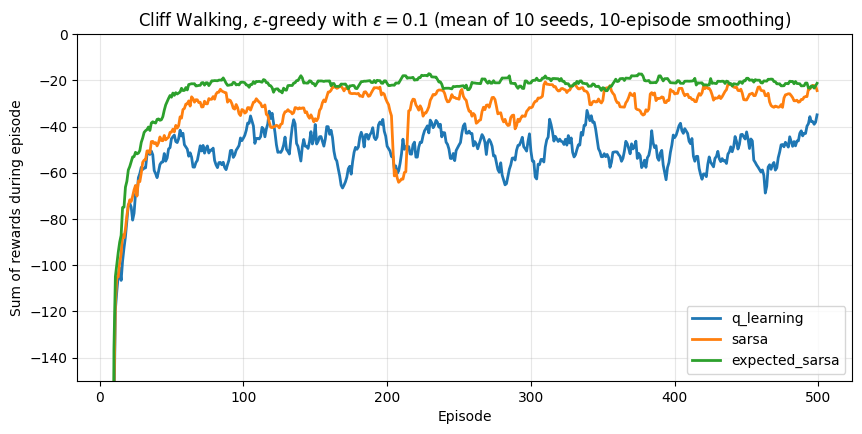

In [6]:
N_SEEDS, N_EPISODES = 10, 500
results = {}
for algo in ["q_learning", "sarsa", "expected_sarsa"]:
    runs = []
    for seed in range(N_SEEDS):
        Q, rets = train_td_control(cliff_env, algo, n_episodes=N_EPISODES, alpha=0.5, gamma=1.0, epsilon=0.1, seed=seed)
        runs.append(rets)
    results[algo] = dict(Q=Q, returns=np.array(runs))   # keep the last seed's Q-table for visualization
    print(f"{algo:15s}: mean return over the last 100 episodes = {np.mean(results[algo]['returns'][:, -100:]):.1f}")

plt.figure(figsize=(10, 4.5))
for algo, res in results.items():
    mean = res["returns"].mean(0)
    smooth = np.convolve(mean, np.ones(10) / 10, mode="valid")
    plt.plot(np.arange(len(smooth)) + 9, smooth, lw=2, label=algo)
plt.ylim(-150, 0)
plt.xlabel("Episode")
plt.ylabel("Sum of rewards during episode")
plt.title(r"Cliff Walking, $\varepsilon$-greedy with $\varepsilon = 0.1$ (mean of 10 seeds, 10-episode smoothing)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Reading the plot.** Q-learning learns the *optimal* $Q^*$ and the optimal cliff-edge path — yet its *online*
performance is worse than SARSA's, because its $\varepsilon$-greedy behavior keeps falling off the cliff. SARSA
accounts for exploration in its value estimates and learns the safer path, so it collects more reward *while training*.
Expected SARSA removes the variance in SARSA's target and typically does best of all.

### 6.1 The learned policies

Let's draw the greedy policy of each algorithm as arrows and the state values $\max_a Q(s,a)$ as a heatmap.

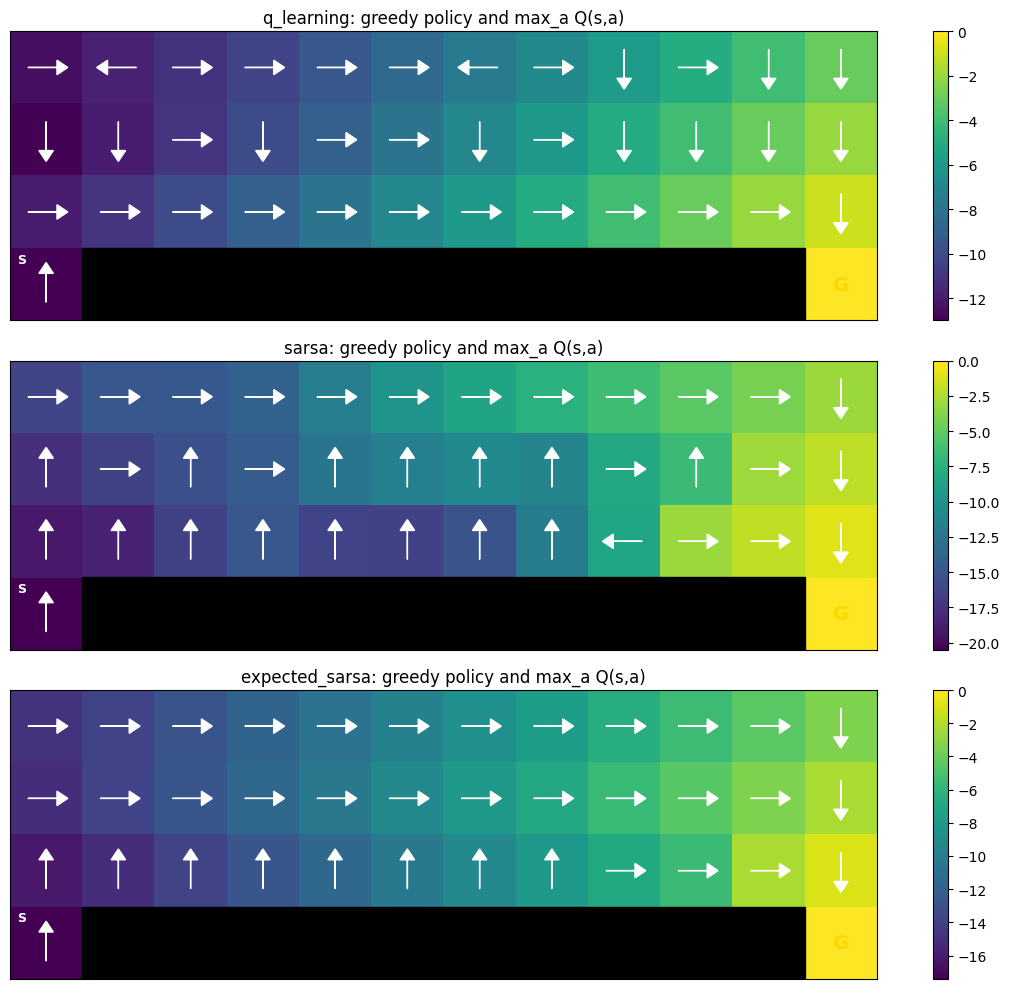

In [7]:
ARROWS = {0: (0, -1), 1: (1, 0), 2: (0, 1), 3: (-1, 0)}   # Up, Right, Down, Left as (dx, dy) in image coordinates


def plot_cliff_policy(Q, title, ax):
    V = Q.max(1).reshape(nrow, ncol)
    im = ax.imshow(V, cmap="viridis")
    for r in range(nrow):
        for c in range(ncol):
            s = r * ncol + c
            if r == nrow - 1 and 0 < c < ncol - 1:
                ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="black"))
                continue
            if s == nS - 1:
                ax.text(c, r, "G", ha="center", va="center", color="gold", fontsize=14, weight="bold")
                continue
            if s == (nrow - 1) * ncol:
                ax.text(c - 0.4, r - 0.3, "S", color="white", fontsize=9, weight="bold")
            dx, dy = ARROWS[int(Q[s].argmax())]
            ax.arrow(c - 0.25 * dx, r - 0.25 * dy, 0.4 * dx, 0.4 * dy,
                     head_width=0.2, head_length=0.15, fc="white", ec="white", lw=1)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title)
    return im


fig, axes = plt.subplots(3, 1, figsize=(12, 10))
for ax, (algo, res) in zip(axes, results.items()):
    im = plot_cliff_policy(res["Q"], f"{algo}: greedy policy and max_a Q(s,a)", ax)
    plt.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout()
plt.show()

Q-learning's arrows run straight along the cliff edge; SARSA's route climbs away from it first. Both are "correct"
answers to *different questions*: "what is the best I could do?" versus "what is the best I can do while I keep
exploring 10% of the time?".

### 6.2 Greedy evaluation

Once training is over, we can switch exploration off ($\varepsilon = 0$) and compare the *greedy* policies. Now
Q-learning's optimal path shines.

In [8]:
def evaluate_greedy(env, Q, n_episodes=20, max_steps=500, seed=1000):
    rets = []
    for i in range(n_episodes):
        s, _ = env.reset(seed=seed + i)
        ep_ret = 0.0
        for _ in range(max_steps):
            s, r, terminated, truncated, _ = env.step(int(Q[s].argmax()))
            ep_ret += r
            if terminated or truncated:
                break
        rets.append(ep_ret)
    return np.mean(rets)


for algo, res in results.items():
    print(f"{algo:15s}: greedy return = {evaluate_greedy(cliff_env, res['Q']):.1f}   (optimal = -13)")

q_learning     : greedy return = -13.0   (optimal = -13)
sarsa          : greedy return = -17.0   (optimal = -13)
expected_sarsa : greedy return = -15.0   (optimal = -13)


## 7. Scaling Up: Q-Learning on Taxi-v3

Cliff Walking has 48 states. `Taxi-v3` has **500** states (taxi position × passenger location × destination) and 6
actions, with a reward of $+20$ for a successful drop-off, $-10$ for illegal pick-up/drop-off, and $-1$ per step.
Tabular Q-learning still handles it easily; we now *decay* $\varepsilon$ over training so that the final policy is
nearly greedy, and use a discount $\gamma = 0.95$.

trained in 3.7s
greedy return over 500 episodes: 8.21   (an optimal policy averages about 8)


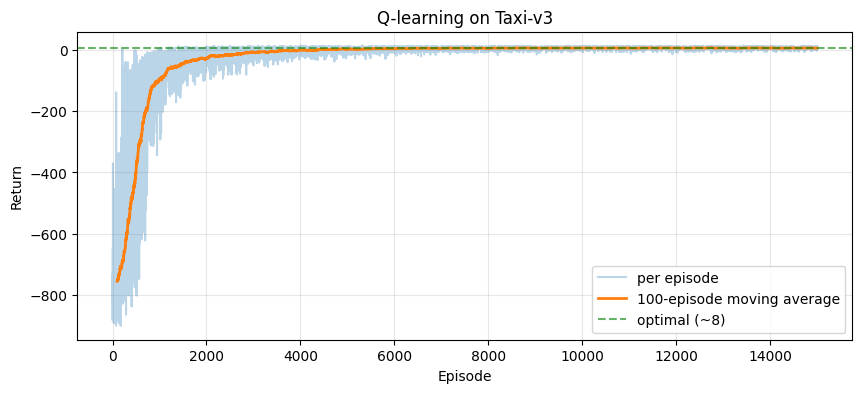

In [9]:
taxi_env = gym.make("Taxi-v3")
t0 = time.time()
Q_taxi, taxi_returns = train_td_control(
    taxi_env, "q_learning", n_episodes=15_000, alpha=0.2, gamma=0.95,
    epsilon=1.0, epsilon_decay=0.9995, epsilon_min=0.01, max_steps=200, seed=SEED)
print(f"trained in {time.time() - t0:.1f}s")
print(f"greedy return over 500 episodes: {evaluate_greedy(taxi_env, Q_taxi, n_episodes=500):.2f}   (an optimal policy averages about 8)")

plt.figure(figsize=(10, 4))
plt.plot(taxi_returns, alpha=0.3, label="per episode")
sm = np.convolve(taxi_returns, np.ones(100) / 100, mode="valid")
plt.plot(np.arange(len(sm)) + 99, sm, lw=2, label="100-episode moving average")
plt.axhline(8, color="green", ls="--", alpha=0.6, label="optimal (~8)")
plt.xlabel("Episode"); plt.ylabel("Return"); plt.title("Q-learning on Taxi-v3")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 8. Visual Demonstration

First the two cliff walkers side by side: Q-learning hugging the edge, SARSA taking the scenic route. Then the taxi
picking up and dropping off a passenger.

q_learning  : return -13 in 13 steps


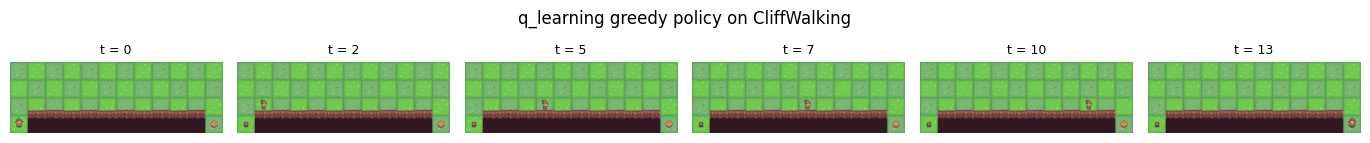

sarsa       : return -17 in 17 steps


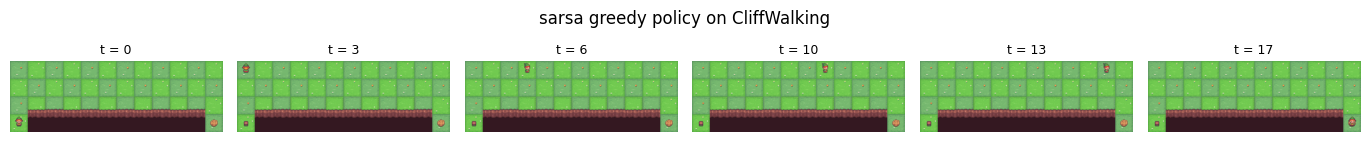

In [10]:
cliff_render = gym.make("CliffWalking-v1", render_mode="rgb_array")
demo_frames = {}
for algo in ["q_learning", "sarsa"]:
    Q = results[algo]["Q"]
    frames, ep_ret, ep_len = record_episode(cliff_render, lambda s, Q=Q: int(Q[s].argmax()), seed=0, max_steps=100)
    demo_frames[algo] = frames
    print(f"{algo:12s}: return {ep_ret:.0f} in {ep_len} steps")
    show_filmstrip(frames, n=6, title=f"{algo} greedy policy on CliffWalking")
cliff_render.close()

top: Q-learning (cliff edge), bottom: SARSA (safe path)


Saved media/q_learning_vs_sarsa_cliff.gif  (18 frames, 0.07 MB)


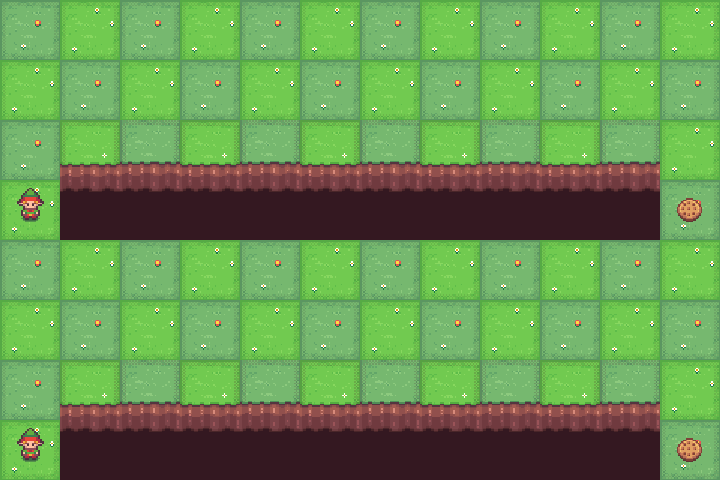

In [11]:
# One GIF with both agents stacked vertically (frames padded to the same length)
T = max(len(f) for f in demo_frames.values())
pad = lambda fr: fr + [fr[-1]] * (T - len(fr))
stacked = [np.concatenate([a, b], axis=0) for a, b in zip(pad(demo_frames["q_learning"]), pad(demo_frames["sarsa"]))]
print("top: Q-learning (cliff edge), bottom: SARSA (safe path)")
save_gif(stacked, "q_learning_vs_sarsa_cliff", fps=4, downscale=1)

Taxi: return 10 in 11 steps


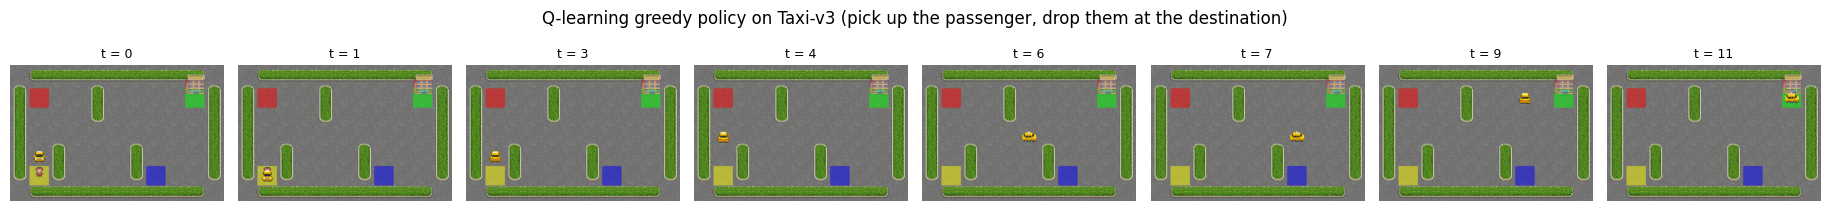

Saved media/q_learning_taxi.gif  (12 frames, 0.40 MB)


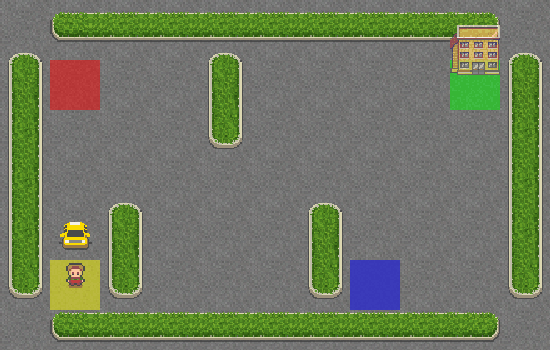

In [12]:
taxi_render = gym.make("Taxi-v3", render_mode="rgb_array")
taxi_frames, taxi_ret, taxi_len = record_episode(taxi_render, lambda s: int(Q_taxi[s].argmax()), seed=7, max_steps=200)
taxi_render.close()
print(f"Taxi: return {taxi_ret:.0f} in {taxi_len} steps")
show_filmstrip(taxi_frames, n=8, title="Q-learning greedy policy on Taxi-v3 (pick up the passenger, drop them at the destination)")
save_gif(taxi_frames, "q_learning_taxi", fps=4, downscale=1)

## 9. Strengths, Weaknesses & Connections

### Strengths

- **Model-free and online.** Learns from raw experience one transition at a time; no need to know or learn $P$.
- **Off-policy.** Data from *any* behavior policy can be used — from a human demonstrator, from old versions of the
  agent, or from a replay buffer. This property is what made experience replay (and therefore DQN) possible.
- **Simple and provably convergent** in the tabular setting.

### Weaknesses

- **Tabular.** A separate entry per $(s,a)$ pair means no generalization: Taxi's 500 states are fine, Atari's
  $256^{84 \times 84 \times 4}$ image states are not. Function approximation is required — and that breaks the
  convergence guarantee (the "deadly triad" of bootstrapping + off-policy + function approximation).
- **Maximization bias.** The $\max_{a'}$ in the target is taken over noisy estimates, which systematically
  *over-estimates* values. **Double Q-learning** (van Hasselt, 2010) fixes this with two tables — and became Double DQN.
- **Exploration is naive.** $\varepsilon$-greedy is dithering, not directed exploration; on sparse-reward tasks it can
  take astronomically long to stumble onto the reward.
- **Step sizes.** Constant $\alpha$ does not satisfy the convergence conditions, and decaying schedules are slow.

### Connections

- **Value iteration** (previous notebook): Q-learning is its sample-based, model-free counterpart.
- **DQN** (Mnih et al., 2013/2015): Q-learning + neural network + experience replay + target network → Atari.
- **Double DQN, Dueling DQN, Rainbow**: refinements of the same TD target.
- **SARSA($\lambda$) / Q($\lambda$)** add eligibility traces to propagate TD errors many steps back — TD-Gammon used
  TD($\lambda$).
- **Actor-critic** methods use TD errors (from a critic) to update a policy (the actor) instead of a Q-table.
- **Offline RL** (CQL, IQL, …) pushes off-policy learning to the extreme: learning entirely from a fixed dataset.

## 10. References

1. **Watkins, C. J. C. H.** (1989). *Learning from Delayed Rewards.* PhD thesis, University of Cambridge.
2. **Watkins, C. J. C. H., & Dayan, P.** (1992). *Q-learning.* Machine Learning, 8, 279–292.
3. **Sutton, R. S.** (1988). *Learning to predict by the methods of temporal differences.* Machine Learning, 3, 9–44.
4. **Rummery, G. A., & Niranjan, M.** (1994). *On-line Q-learning using connectionist systems.* Technical report CUED/F-INFENG/TR 166.
5. **van Seijen, H., van Hasselt, H., Whiteson, S., & Wiering, M.** (2009). *A theoretical and empirical analysis of Expected Sarsa.* IEEE ADPRL.
6. **van Hasselt, H.** (2010). *Double Q-learning.* NeurIPS.
7. **Tesauro, G.** (1995). *Temporal difference learning and TD-Gammon.* Communications of the ACM, 38(3).
8. **Sutton, R. S., & Barto, A. G.** (2018). *Reinforcement Learning: An Introduction* (2nd ed.), Chapter 6. MIT Press.
9. **Mnih, V., et al.** (2015). *Human-level control through deep reinforcement learning.* Nature, 518, 529–533.